In [1]:
from sheap import Sheapectral
import numpy as np
from sheap.Assistants.parser_mapper import summarize_spectral_lines
from utils import median_p16_p84
import matplotlib.pyplot as plt

from astropy.io import fits 
from astropy.table import Table
import os 


import pickle

from matplotlib.lines import Line2D
import pandas as pd 
from utils import *

In [2]:
marker_map = {
    "Wu&Shen22": "o",
    "Pan+25": "s",
    "Sánchez-Sáez+18": "^",
    "Bernal+25": "D",
}

In [3]:
pickle_models = {"Wu&Shen22":"Samples/Wu&Shen22/wushen22_montecarlo_rachi.pkl",
                 "Pan+25":"Samples/Pan+25/Pan25_montecarlo_rachi.pkl",
                  "Sánchez-Sáez+18":"Samples/SanchezSaez18/SS18B_montecarlo_rachi.pkl",
    			"Bernal+25":"Samples/Bernal+25/SS25_montecarlo_sample_rachiv2.pkl",
                 }


pickle_sn2 = {
	"Wu&Shen22": "Samples/Wu&Shen22/signal_2_noise_vs_res_wushen.pkl",
	"Pan+25": "Samples/Pan+25/signal_2_noise_vs_res_pan.pkl",
	"Sánchez-Sáez+18": "Samples/SanchezSaez18/signal_2_noise_vs_res_sanche.pkl",
	"Bernal+25": "Samples/Bernal+25/signal_2_noise_vs_res_bernal.pkl",
}

In [4]:

inner_info = {}
lines = {}
for key,path in pickle_models.items():
	sheapspectral = Sheapectral.from_pickle(path)
	extra_dict = {"z":sheapspectral.z,"chi2_red":sheapspectral.result.chi2_red,"snr":sheapspectral.snr,"min_time":sheapspectral.result.elapsed_time,"mon_time":sheapspectral.result.posterior["montecarlo"]["time_elapsed"],"n_spec":len(sheapspectral.z),"n_params":sheapspectral.result.params.shape[1],
			   "pixel_by_spectra":len(sheapspectral.spectra[:,0,:][0])}
	extra_dict["chi_2_percentiles"]  = median_p16_p84(extra_dict["chi2_red"])
	print(key,len(sheapspectral.spectra[:,0,:][0]))
	if key=="Wu&Shen22":
		mask = sheapspectral.spectra[:, 0, :] > 1300
		out = np.where(mask, sheapspectral.result.residuals, 0.0)
		chi2_red = np.sum(out**2,axis=1)/sheapspectral.result.free_params
		extra_dict["pen_chi2"] = chi2_red
		extra_dict["pen_chi2_percentiles"] = median_p16_p84(chi2_red)
	lines[key] = sheapspectral.result.sheapmodel.lines
	#plt.plot(sheapspectral.result.residuals[0])
	median_chi2 = np.argmin(abs(np.median(sheapspectral.result.chi2_red) - sheapspectral.result.chi2_red))
	median_SN = np.argmin(abs(np.median(sheapspectral.snr) - sheapspectral.snr))
	inner_info[key] = extra_dict

Wu&Shen22 3809
Pan+25 7781
Sánchez-Sáez+18 3808
Bernal+25 2878


In [5]:
# This file can be found in the link {}
dr16_pandas = pd.read_csv("../../dr16q_prop_May01_2024_csv.csv")

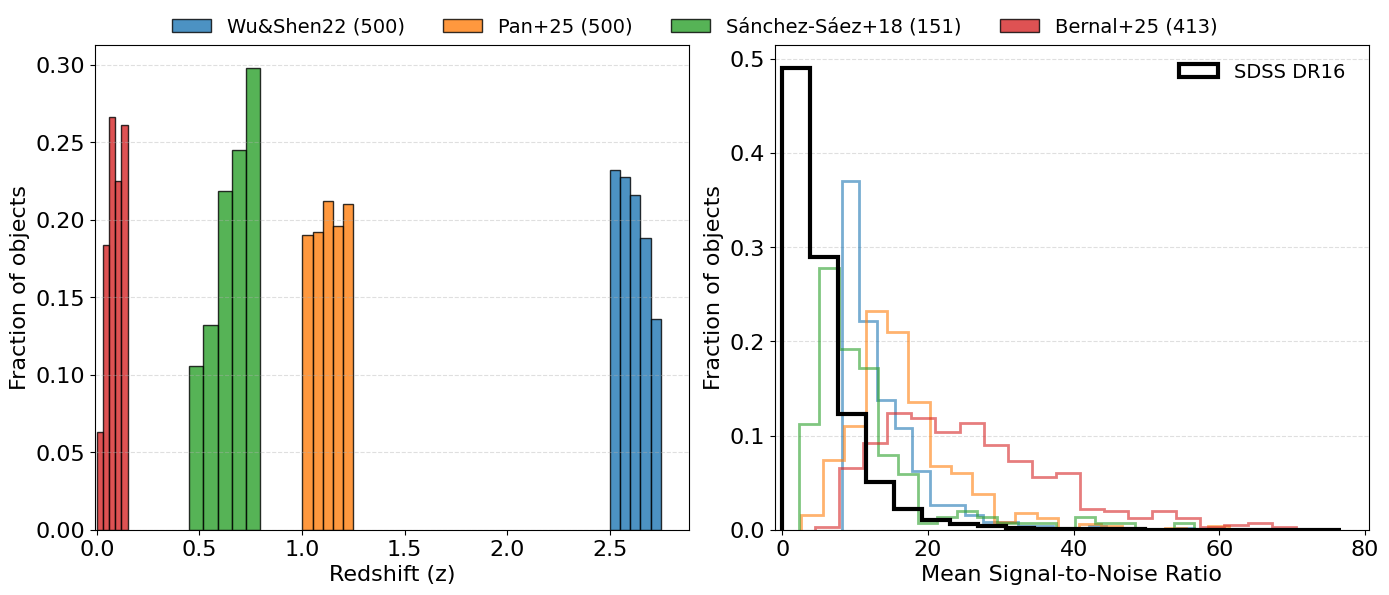

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

for key, inner_dict in inner_info.items():

	
	z_data = inner_dict.get("z")
	z_weights = np.ones_like(z_data) / len(z_data)

	axes[0].hist(
		z_data,
		bins=5,
		edgecolor="black",
		#histtype="stepfilled",
		alpha=0.8,
		label=f"{key} ({len(z_data)})",
		weights=z_weights,
	)

	snr_data = inner_dict.get("snr")
	snr_weights = np.ones_like(snr_data) / len(snr_data)

	axes[1].hist(
		snr_data,
		bins=20,
		#edgecolor="black",
		histtype="step",
		alpha=0.6,
		weights=snr_weights,
		label="_nolegend_",
		lw = 2
	)

sn_dr16 = dr16_pandas["SN_MEDIAN_ALL"].values
mask_dr16 = (
	np.isfinite(sn_dr16)
	& (sn_dr16 > 0.0)
	& (dr16_pandas["Z_DR16Q"].values > 0)
	& (dr16_pandas["Z_FIT"].values > 0)
)
sn_dr16 = sn_dr16[mask_dr16]

sn_dr16_weights = np.ones_like(sn_dr16, dtype=float) / len(sn_dr16)

n, bins, patches = axes[1].hist(
	sn_dr16,
	bins=20,
	histtype="step",
	linewidth=3.0,
	weights=sn_dr16_weights,
	label=f"SDSS DR16",
	color = "k"
)

axes[0].set_xlabel("Redshift (z)", fontsize=16)
axes[0].set_ylabel("Fraction of objects", fontsize=16)
axes[0].tick_params(axis="both", which="major", labelsize=16)
axes[1].set_xlabel("Mean Signal-to-Noise Ratio", fontsize=16)
axes[1].set_ylabel("Fraction of objects", fontsize=16)
axes[1].tick_params(axis="both", which="major", labelsize=16)

for ax in axes:
	ax.grid(axis="y", linestyle="--", alpha=0.4)


handles_top, labels_top = axes[0].get_legend_handles_labels()
fig.legend(
	handles_top,
	labels_top,
	loc="upper center",
	ncol=len(labels_top),
	fontsize=14,
	frameon=False,
)

dr16_handle = patches[0]
axes[1].legend(
	[dr16_handle],
	[f"SDSS DR16 "],#(N={len(sn_dr16)})
	title=None,
	loc="upper right",
	fontsize=14,
	title_fontsize=12,
	frameon=False,
)
axes[0].set_xlim(-0.009,axes[0].get_xlim()[-1])
axes[1].set_xlim(-1,axes[1].get_xlim()[-1])
fig.tight_layout(rect=[0, 0, 1, 0.95])
#fig.savefig("../redshift_snr_fraction.pdf", dpi=300, bbox_inches="tight")
plt.show()


/tmp/ipykernel_944253/1892593826.py:175: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax[1].set_ylim(0,100)


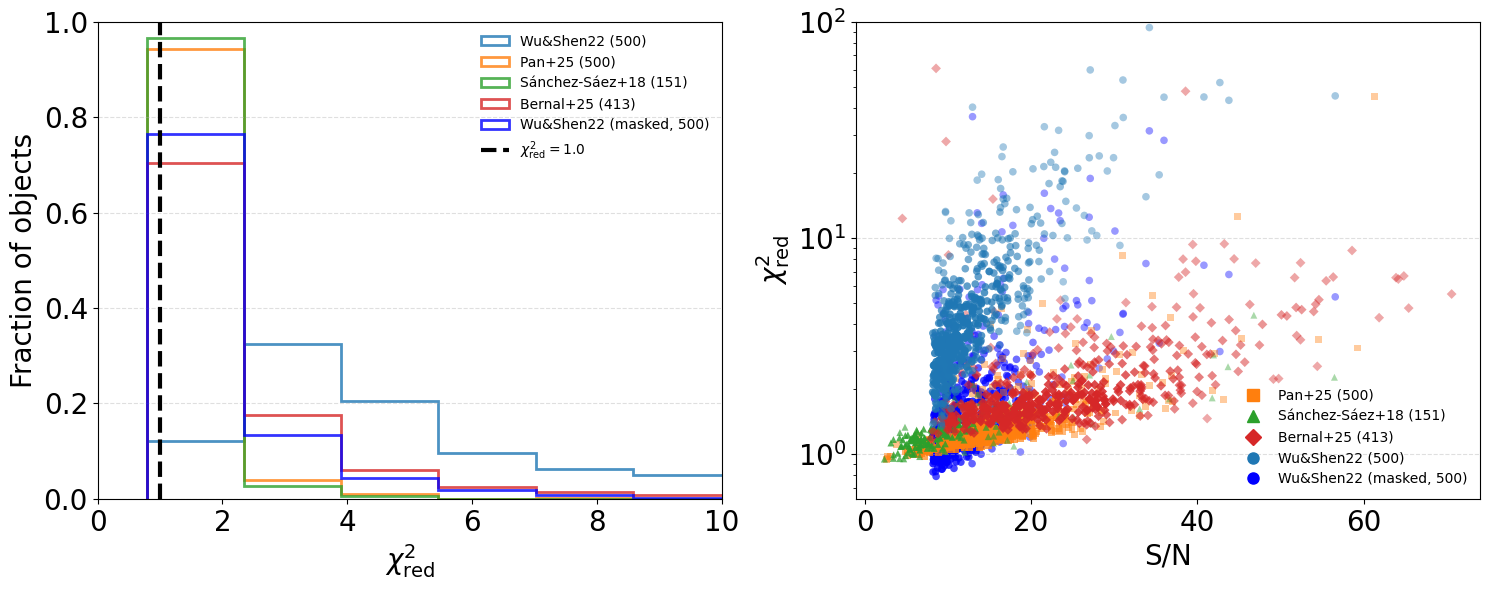

In [ ]:
wu_unmasked_color = "C0"
# masked = explicit blue
wu_masked_color = "blue"

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
fontsize = 20

all_chi2_red = []
for k, d in inner_info.items():
    if d.get("chi2_red") is not None:
        all_chi2_red.append(np.asarray(d["chi2_red"]))
if inner_info.get("Wu&Shen22", {}).get("pen_chi2") is not None:
    all_chi2_red.append(np.asarray(inner_info["Wu&Shen22"]["pen_chi2"]))

all_data = np.concatenate([a[np.isfinite(a)] for a in all_chi2_red if a.size])
bin_edges = np.histogram_bin_edges(all_data, bins=60)

Ns = []
for k, d in inner_info.items():
    x = d.get("chi2_red")
    if x is not None:
        Ns.append(np.isfinite(x).sum())

Ns.append(np.isfinite(inner_info["Wu&Shen22"]["pen_chi2"]).sum())

Ns = np.asarray(Ns, int)
Nmin, Nmax = Ns.min(), Ns.max()

colors = []
for key, inner_dict in inner_info.items():
    data = np.asarray(inner_dict.get("chi2_red"))
    if data is None:
        continue

    data = data[np.isfinite(data)]
    N = data.size
    if N == 0:
        continue

    weights = np.ones_like(data, float) / N

    n, edges, patches = ax[0].hist(
        data,
        bins=bin_edges,
        linewidth= 2.0,
        alpha=0.8,
        label=f"{key} ({N})",
        histtype="step",
        weights=weights,
        zorder=1,
    )
    colors.append(patches[0].get_facecolor())

data = np.asarray(inner_info["Wu&Shen22"].get("pen_chi2"))
data = data[np.isfinite(data)]
N = data.size
if N > 0:
    weights = np.ones_like(data, float) / N
    ax[0].hist(
        data,
        bins=bin_edges,
        histtype="step",
        edgecolor="blue",
        alpha=0.8,
        label=f"Wu&Shen22 (masked, {N})",
        weights=weights,
        zorder=2,
        linewidth= 2.0,
        facecolor="blue",
    )

# --- vertical reference line (keep its handle) ---
line = ax[0].axvline(
    1.0, zorder=10, lw=3, color="k", ls="--",
    label=r"$\chi^2_{\rm red}=1.0$"
)
ax[0].legend(frameon=False)
ax[0].set_xlim(0,10)
ax[0].set_ylim(0,1)
ax[0].set_xlabel(r"$\chi^2_{\rm red}$", fontsize=fontsize)
ax[0].set_ylabel("Fraction of objects", fontsize=fontsize)
ax[0].tick_params(axis="both", which="major", labelsize=fontsize)
ax[0].grid(axis="y", linestyle="--", alpha=0.4)

handles, labels = ax[0].get_legend_handles_labels()
handles_top = [h for h in handles if h is not line]
labels_top  = [l for h, l in zip(handles, labels) if h is not line]
###################################################################
cycle = ["C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8", "C9"]

alpha_min = 0.40  # your requirement: least dense still visible
alpha_max = 1.00
power = 0.7       # lower -> more contrast in dense cores

# --- plot non-Wu samples with their own standard colors ---
i = 0
legend_handles = []

for key, d in inner_info.items():
    if key == "Wu&Shen22":
        continue

    x = d.get("snr")
    y = d.get("chi2_red")
    if x is None or y is None:
        continue

    base_color = cycle[i % len(cycle)]
    i += 1

    x2, y2, rgba = rgba_by_density(x, y, base_color, alpha_min=alpha_min, alpha_max=alpha_max, power=power)

    ax[1].scatter(
        x2, y2,
        s=25,
        marker=marker_map.get(key, "o"),
        c=rgba,
        edgecolors="none",
        zorder=2,
    )

    legend_handles.append(
        legend_handle(base_color, marker_map.get(key, "o"), f"{key} ({x2.size})", alpha=1.0)
    )

# --- Wu&Shen22 unmasked (standard Matplotlib color C0) ---
if inner_info.get("Wu&Shen22", {}).get("chi2_red") is not None:
    x = inner_info["Wu&Shen22"].get("snr")
    y = inner_info["Wu&Shen22"].get("chi2_red")
    x2, y2, rgba = rgba_by_density(x, y, wu_unmasked_color, alpha_min=alpha_min, alpha_max=alpha_max, power=power)

    ax[1].scatter(
        x2, y2,
        s=30,
        marker=marker_map.get("Wu&Shen22", "o"),
        c=rgba,
        edgecolors="none",
        zorder=3,
    )

    legend_handles.append(
        legend_handle(wu_unmasked_color, marker_map.get("Wu&Shen22", "o"), f"Wu&Shen22 ({x2.size})", alpha=1.0)
    )

# --- Wu&Shen22 masked (explicit blue) ---
if inner_info.get("Wu&Shen22", {}).get("pen_chi2") is not None:
    x = inner_info["Wu&Shen22"].get("snr")
    y = inner_info["Wu&Shen22"].get("pen_chi2")
    x2, y2, rgba = rgba_by_density(x, y, wu_masked_color, alpha_min=alpha_min, alpha_max=alpha_max, power=power)

    ax[1].scatter(
        x2, y2,
        s=30,
        marker=marker_map.get("Wu&Shen22", "o"),
        c=rgba,
        edgecolors="none",
        zorder=1,  # under the unmasked
    )

    legend_handles.append(
        legend_handle(wu_masked_color, marker_map.get("Wu&Shen22", "o"), f"Wu&Shen22 (masked, {x2.size})", alpha=1.0)
    )

# --- axes styling ---
ax[1].set_xlabel("S/N", fontsize=fontsize)
ax[1].set_ylabel(r"$\chi^2_{\rm red}$", fontsize=fontsize)
ax[1].set_yscale("log")
ax[1].grid(axis="y", linestyle="--", alpha=0.4)
ax[1].tick_params(axis="both", which="major", labelsize=fontsize)
ax[1].set_ylim(0,100)
# legend shows the *least dense* appearance (~alpha_min)
ax[1].legend(
    handles=legend_handles,
    #loc="upper center",
    #bbox_to_anchor=(0.5, 1.18),
    #ncol=1,
    frameon=False,
    fontsize=10,
)
#
fig.tight_layout()
#fig.savefig("SNchi2plots.pdf", dpi=300, bbox_inches="tight")
plt.show()

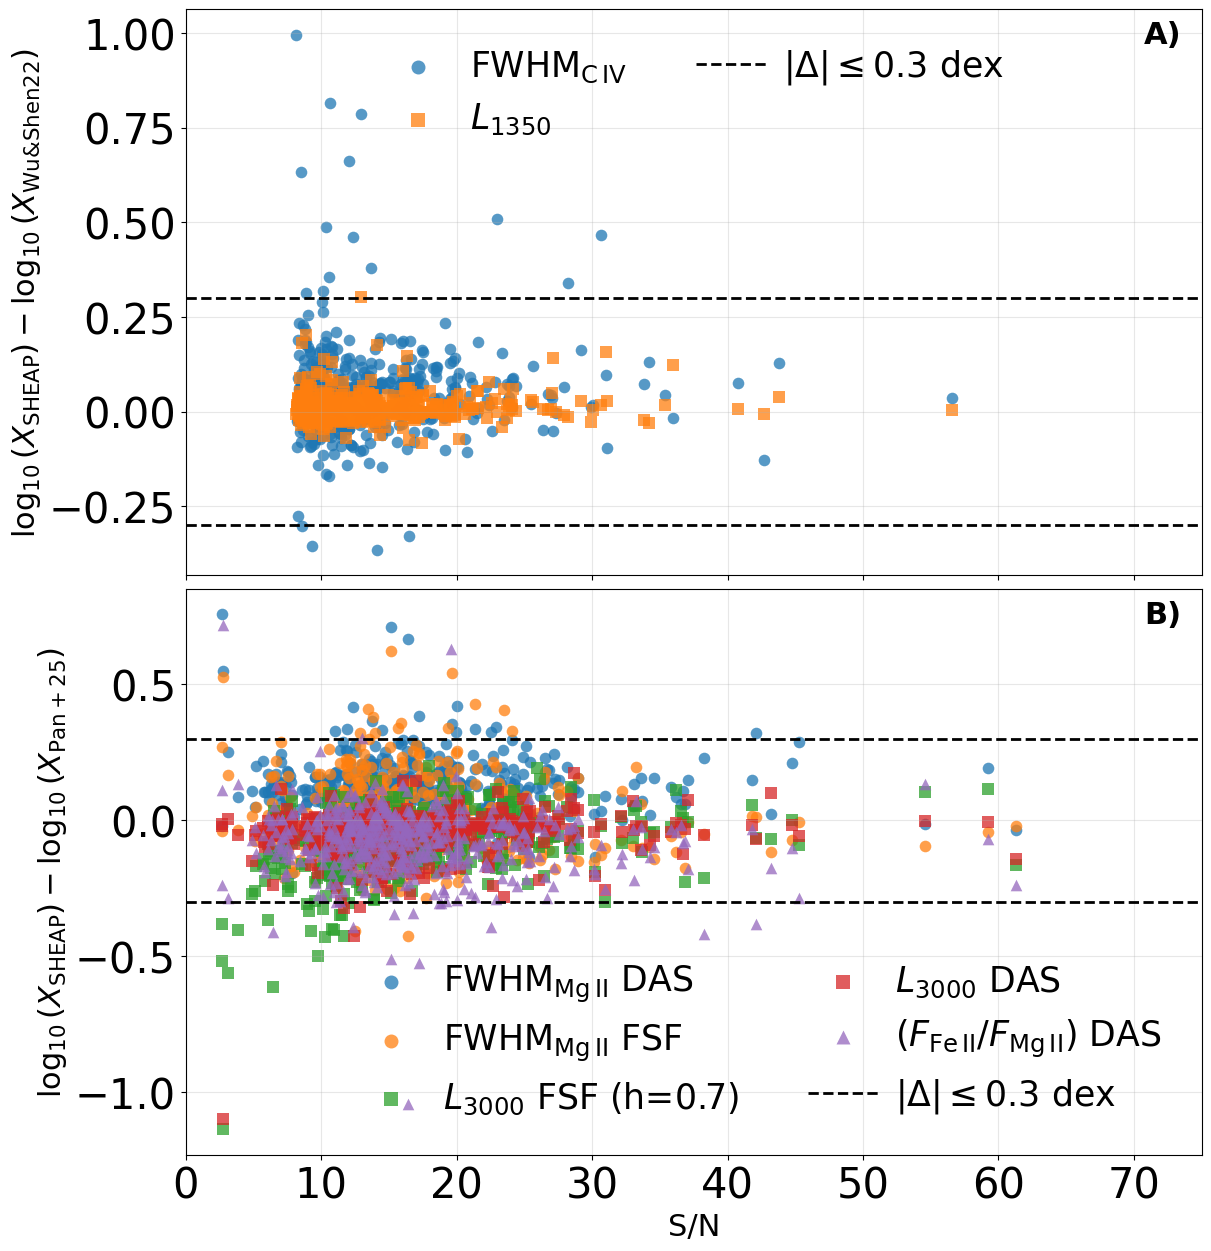

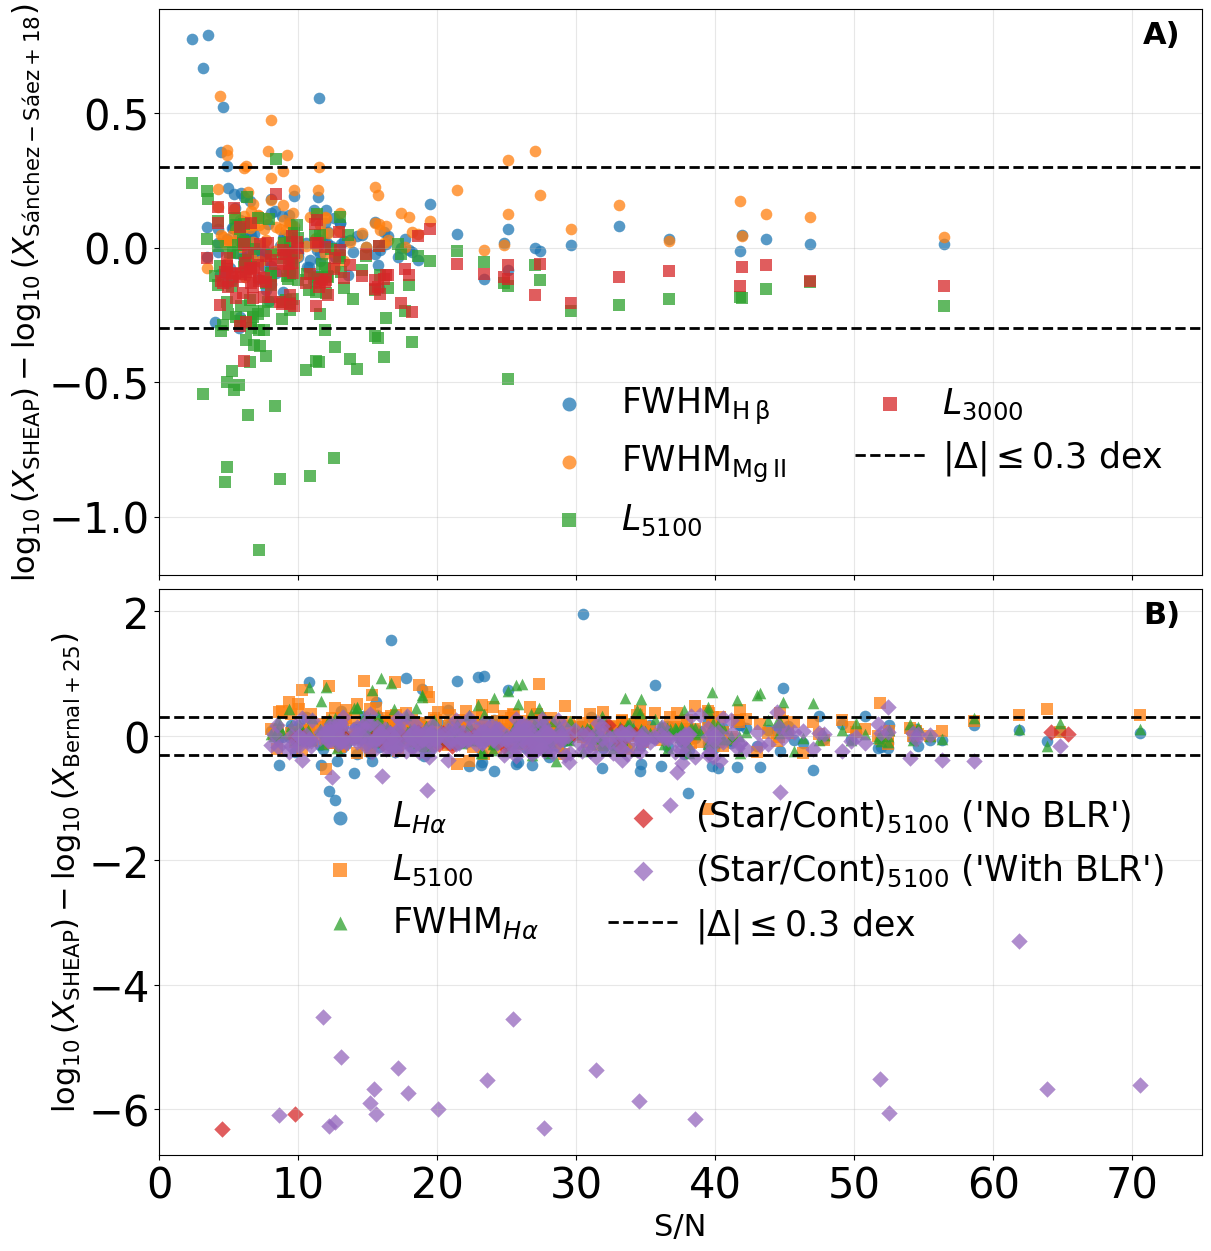

In [8]:
fs_label  = 22
fs_ticks  = 30
fs_legend = 25
marker_size = 70
alpha_val = 0.75



items = list(pickle_sn2.items())
pairs = [items[i:i+2] for i in range(0, len(items), 2)]

for pair_idx, pair in enumerate(pairs, start=1):

	fig, axes = plt.subplots(
		nrows=len(pair),
		ncols=1,
		figsize=(12, 6.2 * len(pair)),
		sharex=True,
		constrained_layout=True,          # <- use this instead of tight_layout
		gridspec_kw={"hspace": 0.01},     # <- reduce separation here
	)

	if len(pair) == 1:
		axes = [axes]

	panel_labels = ["A)", "B)"]  # reset per figure

	for j, (ax, (master_k, _pickle)) in enumerate(zip(axes, pair)):

		with open(_pickle, "rb") as f:
			obj_loaded = pickle.load(f)

		for key, values in obj_loaded.items():
			x_plot = values.get("x")
			y_plot = values.get("y")
			marker = values.get("marker", "o")

			ax.scatter(
				x_plot, y_plot,
				marker=marker,
				s=marker_size,
				alpha=alpha_val,
				label=key,
				linewidths=0.0
			)

		ax.axhline(0.3, linestyle="--", linewidth=2, c="k")
		ax.axhline(-0.3, linestyle="--", linewidth=2, c="k",
				   label=rf"$|\Delta|\leq {0.3}\ \mathrm{{dex}}$")

		mk = str(master_k).replace("_", r"\_")
		ax.set_ylabel(
			rf"$\log_{{10}}(X_{{\rm SHEAP}}) - \log_{{10}}(X_{{\rm {mk}}})$",
			fontsize=fs_label
		)

		ax.tick_params(axis="both", which="major", labelsize=fs_ticks)
		ax.tick_params(axis="both", which="minor", labelsize=fs_ticks - 2)
		
		ax.grid(True, alpha=0.3)

		ax.legend(
			fontsize=fs_legend,
			frameon=False,
			loc="best",
			markerscale=1.2,
			handletextpad=0.5,
			borderpad=0.6,
			ncol=2
		)

		ax.text(
			0.98, 0.98, panel_labels[j],
			transform=ax.transAxes,
			ha="right", va="top",
			fontsize=fs_label,
			fontweight="bold",
		)
	axes[-1].set_xlim(0,75)
	axes[-1].set_xlabel("S/N", fontsize=fs_label)

	#fig.savefig(f"signal_2_noise_pairs_{pair_idx}.pdf", dpi=300, bbox_inches="tight")
	plt.show()


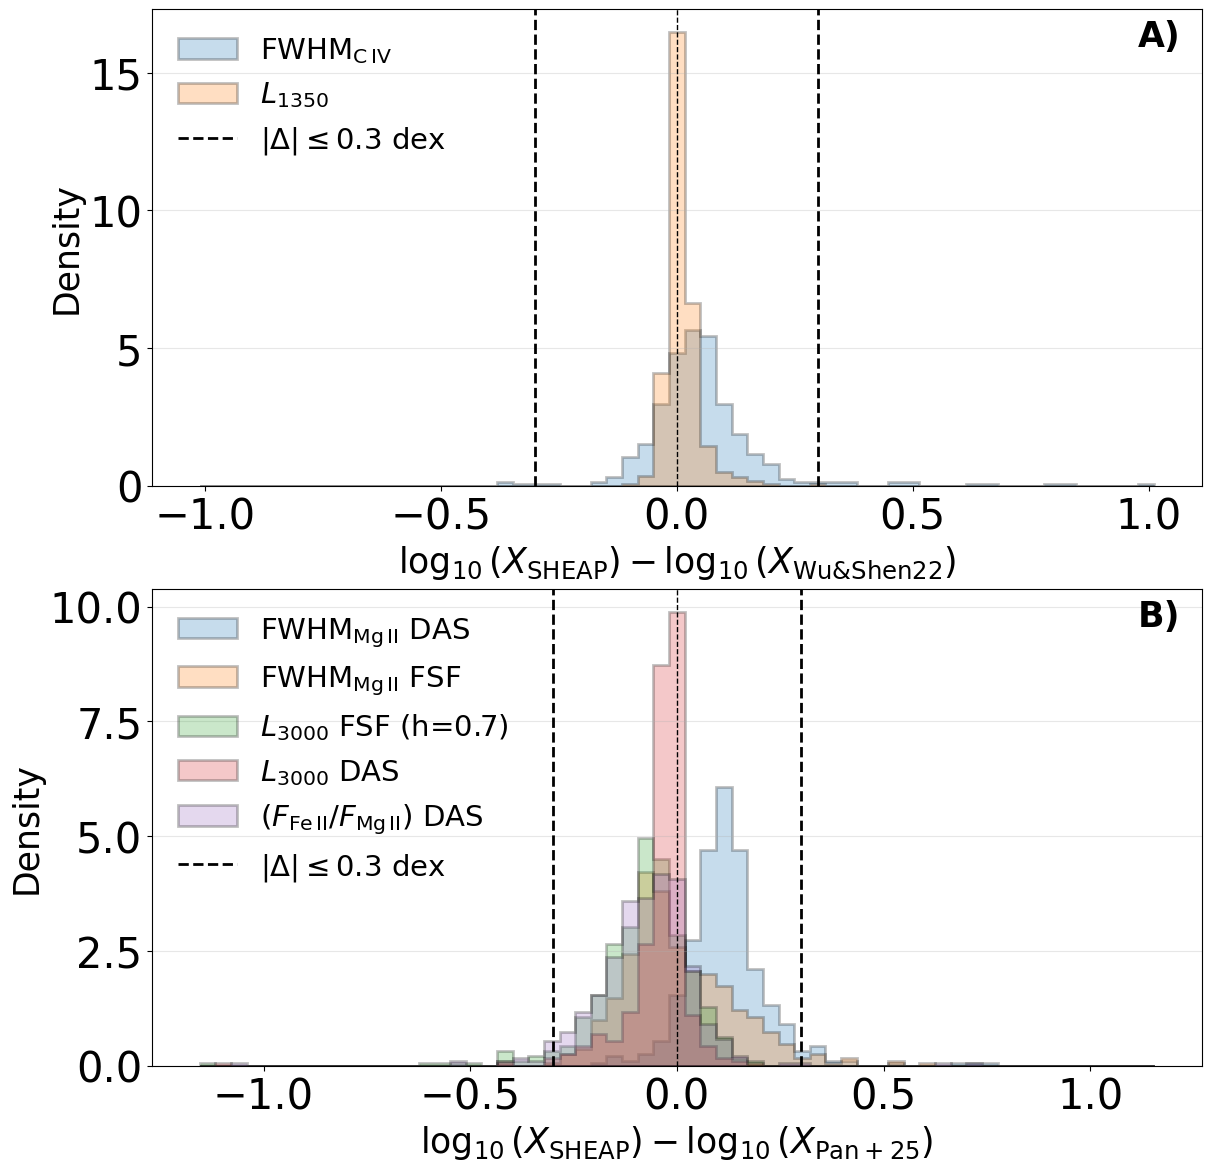

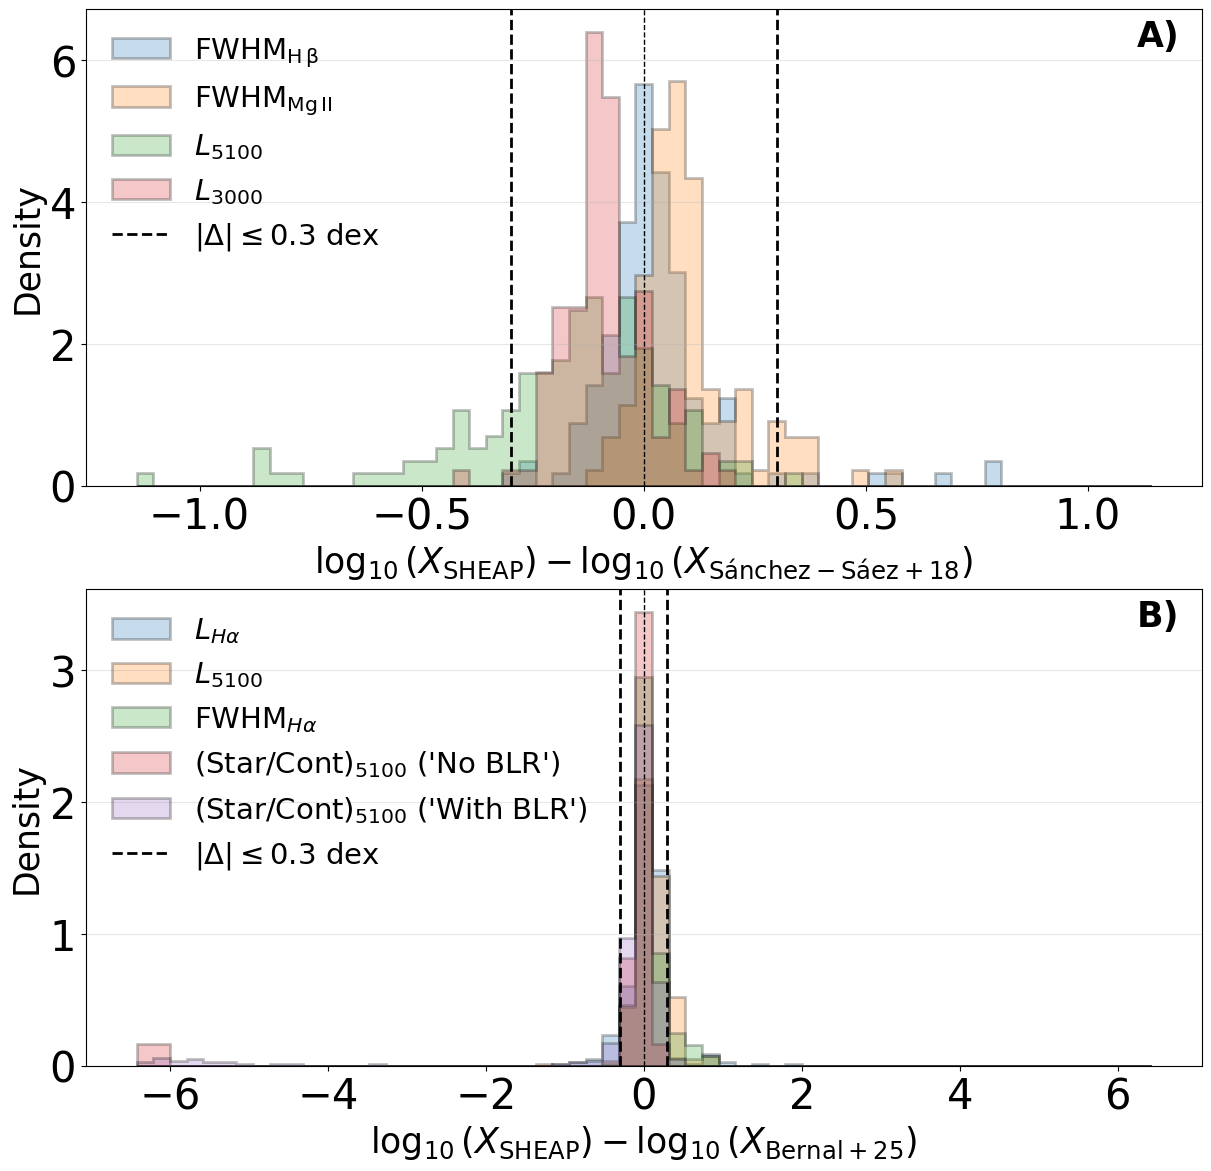

In [ ]:
fs_label  = 25
fs_ticks  = 30
fs_legend = 21
alpha_val = 0.25

density = True
nbins = 60
clip = None          
band = 0.30          


items = list(pickle_sn2.items())
pairs = [items[i:i+2] for i in range(0, len(items), 2)]

for pair_idx, pair in enumerate(pairs, start=1):

    fig, axes = plt.subplots(
        nrows=len(pair),
        ncols=1,
        figsize=(12, 5.8 * len(pair)),
        sharex=False,                    
        constrained_layout=True,
        gridspec_kw={"hspace": 0.01},
    )
    if len(pair) == 1:
        axes = [axes]

    panel_labels = ["A)", "B)"]          

    for j, (ax, (master_k, _pickle)) in enumerate(zip(axes, pair)):

        with open(_pickle, "rb") as f:
            obj_loaded = pickle.load(f)

        # ---- collect ALL y values across keys for common bins in this panel ----
        y_all_chunks = []
        for key, values in obj_loaded.items():
            y = values.get("y")
            if y is None:
                continue
            y_all_chunks.append(np.asarray(y, float).ravel())

        y_all = np.concatenate(y_all_chunks) if y_all_chunks else np.array([])
        edges = bins_centered_on_zero(y_all, nbins=nbins, clip=clip)

        # ---- plot one histogram per sub-sample (key) ----
        for key, values in obj_loaded.items():
            y = values.get("y")
            if y is None:
                continue
            y = np.asarray(y, float).ravel()
            y = y[np.isfinite(y)]

            ax.hist(
                y,
                bins=edges,
                density=density,
                histtype="stepfilled",
                edgecolor="black",
                linewidth=2.0,
                alpha=alpha_val,
                label=key,
            )

        ax.axvline(0.0, linestyle="--", linewidth=1.0, c="k")
        ax.axvline(+band, linestyle="--", linewidth=2.0, c="k")
        ax.axvline(-band, linestyle="--", linewidth=2.0, c="k")

        mk = str(master_k).replace("_", r"\_")
        ax.set_xlabel(
            rf"$\log_{{10}}(X_{{\rm SHEAP}}) - \log_{{10}}(X_{{\rm {mk}}})$",
            fontsize=fs_label
        )
        ax.set_ylabel("Density" if density else "Count", fontsize=fs_label)

        ax.tick_params(axis="both", which="major", labelsize=fs_ticks)
        ax.tick_params(axis="both", which="minor", labelsize=fs_ticks - 2)
        ax.grid(axis="y", alpha=0.3)

    
        handles, labels = ax.get_legend_handles_labels()
        band_handle = Line2D([], [], linestyle="--", linewidth=2.0, color="k",
                             label=rf"$|\Delta|\leq {band:.1f}\ \mathrm{{dex}}$")

        ax.legend(
            handles + [band_handle],
            labels + [band_handle.get_label()],
            fontsize=fs_legend,
            frameon=False,
            loc="best",
        )

        # ---- panel tag ----
        ax.text(
            0.98, 0.98, panel_labels[j],
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=fs_label,
            fontweight="bold",
        )

        x0, x1 = ax.get_xlim()
        m = max(abs(x0), abs(x1))
        ax.set_xlim(-m, m)

    #fig.savefig(f"residual_hist_pairs_{pair_idx}.pdf", dpi=300, bbox_inches="tight")
    plt.show()
